# Plots mit Matplotlib: lineare Funktionen und Potenzgesetze

Dieses Notebook löst die Aufgabenliste aus `python_setup.md` Schritt für Schritt und erklärt jeden Schritt.

Führe jede Code-Zelle mit `Shift + Enter` aus, am besten der Reihe nach von oben nach unten.

## Vorbereitung: Bibliotheken importieren

Wir brauchen:
- `numpy`: zum Rechnen mit Zahlen-Arrays (siehe `python_setup.md`, sollte schon installiert sein).
- `matplotlib.pyplot`: zum Plotten.
- `ipywidgets`: für den interaktiven Schieberegler in Aufgabe 6. Falls das Notebook beim Import einen Fehler wirft, einmalig im Terminal (in der aktivierten `akademie2026`-Umgebung) installieren:

  `conda install -c conda-forge ipywidgets`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

---
## Aufgabe 1: lineare Funktion definieren

Eine lineare Funktion hat die Form

$$y = m \cdot x + b$$

mit **Steigung** $m$ und **y-Achsenabschnitt** $b$ (der Wert von $y$ bei $x=0$). Wir schreiben das als Python-Funktion mit `m` und `b` als Argumenten samt Standardwerten, damit man sie ohne Angabe direkt ausprobieren kann.

In [2]:
def linear(x, m=2.0, b=1.0):
    return m * x + b

x = np.linspace(-5, 5, 100)   # 100 gleichmaessig verteilte x-Werte zwischen -5 und 5
y = linear(x)

print(x[:5])   # die ersten 5 x-Werte zur Kontrolle
print(y[:5])   # die dazugehoerigen y-Werte

[-5.        -4.8989899 -4.7979798 -4.6969697 -4.5959596]
[-9.         -8.7979798  -8.5959596  -8.39393939 -8.19191919]


---
## Aufgabe 2 & 3: Graph plotten, Titel und Achsenbeschriftung

`plt.plot(x, y)` zeichnet die Punkte und verbindet sie mit Linien. Danach ergänzen wir:

- `plt.title(...)` — Überschrift
- `plt.xlabel(...)`, `plt.ylabel(...)` — Achsenbeschriftung
- `plt.grid(True)` — Hilfslinien, erleichtern das Ablesen
- `plt.show()` — zeigt den fertigen Plot an

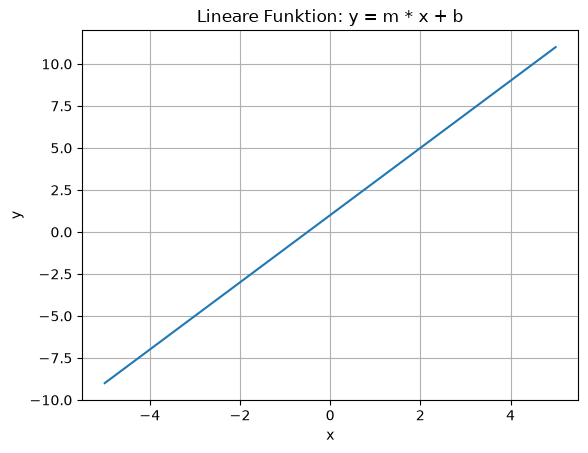

In [3]:
plt.plot(x, y)
plt.title("Lineare Funktion: y = m * x + b")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

---
## Aufgabe 4: Potenzgesetz definieren und plotten

Ein Potenzgesetz hat die Form

$$y = a \cdot x^{b}$$

mit **Koeffizient** $a$ und **Exponent** $b$. Da $b$ auch nicht-ganzzahlig sein kann (z. B. $b=1.5$), ist $x^b$ für negative $x$ nicht immer definiert — deshalb verwenden wir hier nur positive $x$-Werte.

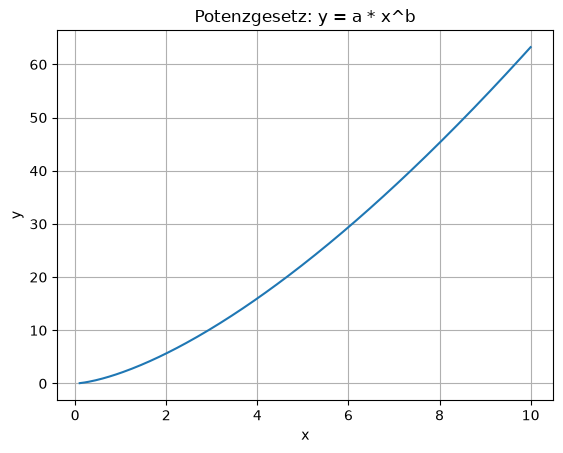

In [4]:
def power_law(x, a=1.0, b=2.0):
    return a * x**b

x_pos = np.linspace(0.1, 10, 200)          # nur positive x-Werte
y_pow = power_law(x_pos, a=2.0, b=1.5)

plt.plot(x_pos, y_pow)
plt.title("Potenzgesetz: y = a * x^b")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

---
## Aufgabe 5: doppelt-logarithmischer Plot

Statt beide Achsen linear (gleichmäßige Abstände zwischen Zahlen) darzustellen, tragen wir jetzt $\log(x)$ gegen $\log(y)$ auf. `plt.loglog(x, y)` macht das in einem Schritt (entspricht `plt.plot` + `plt.xscale("log")` + `plt.yscale("log")`).

`plt.grid(True, which="both")` zeigt Gitterlinien auch für die Zwischenwerte (2, 3, 4, ... zwischen den Zehnerpotenzen), das ist bei Log-Achsen hilfreich zum Ablesen.

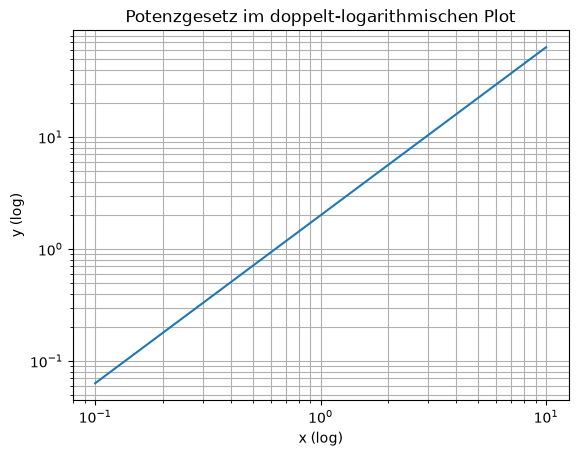

In [5]:
plt.loglog(x_pos, y_pow)
plt.title("Potenzgesetz im doppelt-logarithmischen Plot")
plt.xlabel("x (log)")
plt.ylabel("y (log)")
plt.grid(True, which="both")
plt.show()

### Verständnisfrage 1: Welche Steigung weist der Graph aus Aufgabe 5 auf? Warum?

Der Graph ist eine **Gerade** mit Steigung $b$ (hier also $b=1.5$).

**Warum:** Wir logarithmieren beide Seiten von $y = a \cdot x^b$:

$$\log(y) = \log(a) + b \cdot \log(x)$$

Das ist eine **lineare Gleichung** in $\log(x)$ und $\log(y)$, vergleiche mit $y = m \cdot x + b$ aus Aufgabe 1: hier entspricht $\log(x)$ dem $x$, $\log(y)$ dem $y$, der Exponent $b$ übernimmt die Rolle der Steigung $m$, und $\log(a)$ die Rolle des Achsenabschnitts. Ein Potenzgesetz erscheint deshalb im doppelt-logarithmischen Plot immer als Gerade, das ist ein beliebter Trick, um in Messdaten zu prüfen, ob ein Potenzgesetz vorliegt, und um seinen Exponenten $b$ direkt als Steigung abzulesen.

---
## Aufgabe 6: interaktiver Plot mit variablem Koeffizienten

Mit `ipywidgets.interact` können wir eine Funktion an einen Schieberegler koppeln: jedes Mal, wenn der Regler bewegt wird, wird die Funktion mit dem neuen Wert erneut aufgerufen und der Plot neu gezeichnet.

Wir packen unseren Plot aus Aufgabe 4 in eine Funktion `plot_power_law(a)`, die den Koeffizienten `a` als Argument entgegennimmt. `interact(plot_power_law, a=(0.1, 5.0, 0.1))` erzeugt daraus automatisch einen Schieberegler von 0.1 bis 5.0 in Schritten von 0.1.

`plt.ylim(0, 60)` legt die y-Achse fest, damit man die Skalierung des Graphen beim Verschieben des Reglers gut beobachten kann (sonst würde Matplotlib die Achse bei jedem Aufruf neu an die Daten anpassen).

In [ ]:
def plot_power_law(a=1.0):
    x = np.linspace(0.1, 10, 200)
    y = power_law(x, a=a, b=1.5)

    plt.figure()
    plt.plot(x, y)
    plt.title(f"Potenzgesetz: y = {a:.1f} * x^1.5")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.ylim(0, 60)
    plt.grid(True)
    plt.show()

interact(plot_power_law, a=(0.1, 5.0, 0.1));   # Schieberegler von 0.1 bis 5.0 in 0.1er-Schritten

interactive(children=(FloatSlider(value=1.0, description='a', max=5.0, min=0.1), Output()), _dom_classes=('wid…

### Verständnisfrage 2: Wie verändert sich der Graph aus Aufgabe 6 durch die Skalierung des Koeffizienten?

Der Koeffizient $a$ **streckt oder staucht** die Kurve entlang der y-Achse (vertikale Skalierung), ohne ihre **Form** zu verändern: Jeder $y$-Wert wird mit $a$ multipliziert. Ein größeres $a$ macht die Kurve für jedes $x$ proportional höher (steilerer Anstieg), ein kleineres $a$ flacher. Die Nullstelle bleibt bei $x=0$ und die grundsätzliche Krümmung (bestimmt durch den Exponenten $b$) ändert sich nicht, nur der Exponent $b$ würde die Form der Kurve verändern, nicht $a$.